<a href="https://colab.research.google.com/github/subhranilghosh573/project2/blob/main/Obesity_Prediction_and_Diet_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



>Import Libraries



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Load Dataset

In [2]:
df = pd.read_csv('/content/new.csv')

df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Understand Dataset

In [3]:
print(df.shape)

df.info()

df.describe()

(2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                    

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


Check Missing Values

In [4]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


Exploratory Data Analysis

Target Distribution

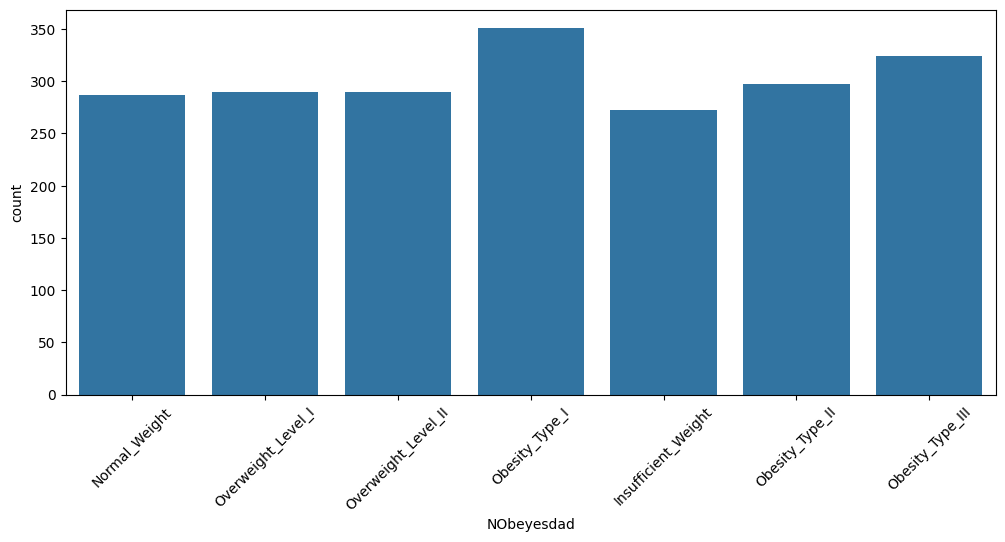

In [5]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='NObeyesdad',
    data=df
)

plt.xticks(rotation=45)

plt.show()

Age Distribution

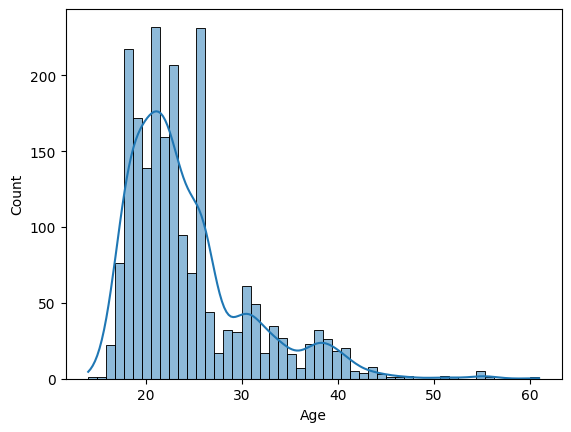

In [6]:
sns.histplot(
    df['Age'],
    kde=True
)

plt.show()

Weight Distribution

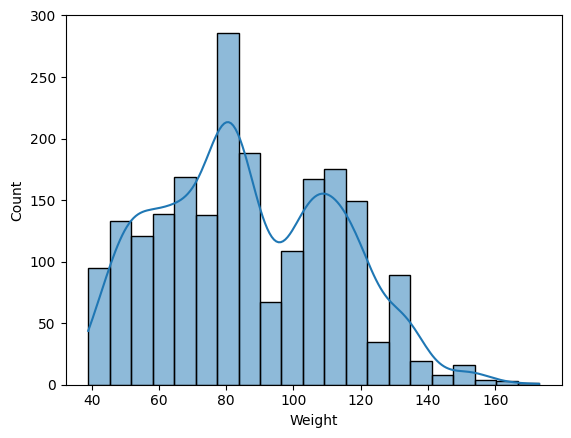

In [7]:
sns.histplot(
    df['Weight'],
    kde=True
)

plt.show()

Correlation Heatmap

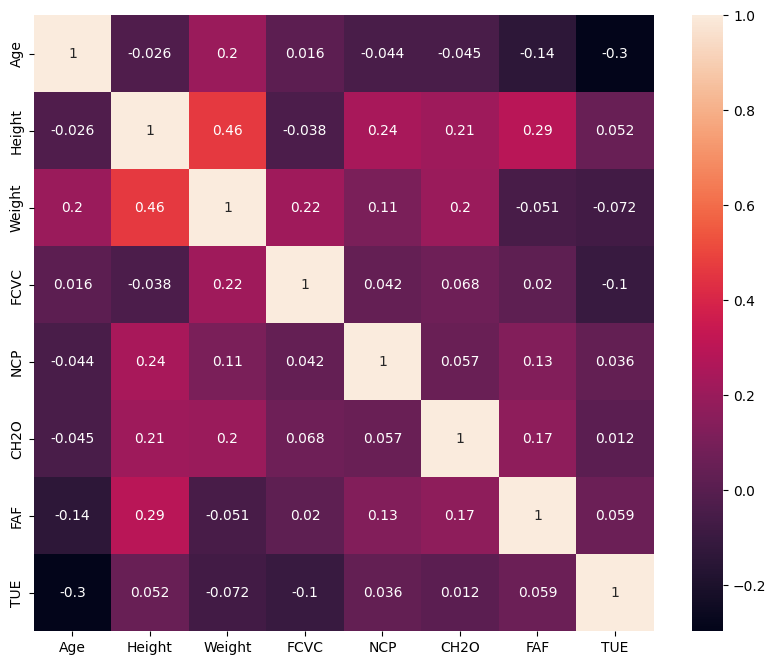

In [8]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.show()

Encode Categorical Features

In [9]:
label_encoders = {}

for col in df.columns:

    if df[col].dtype == 'object':

        le = LabelEncoder()

        df[col] = le.fit_transform(df[col])

        label_encoders[col] = le

Feature and Target Separation

In [10]:
X = df.drop('NObeyesdad',axis=1)

y = df['NObeyesdad']

Train-Test Split

In [11]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(1688, 16)
(423, 16)


Logistic Regression

In [13]:
lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Metrics

In [14]:
lr_acc = accuracy_score(
    y_test,
    lr_pred
)

lr_prec = precision_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_rec = recall_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average='weighted'
)

print("Accuracy =",lr_acc)
print("Precision =",lr_prec)
print("Recall =",lr_rec)
print("F1 =",lr_f1)

Accuracy = 0.8392434988179669
Precision = 0.841926621447898
Recall = 0.8392434988179669
F1 = 0.835567021175678


Logistic Regression Confusion Matrix

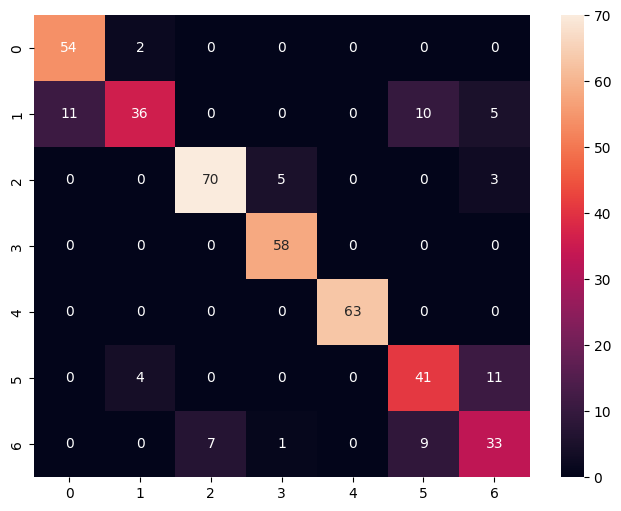

In [15]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

Random Forest

In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

Random Forest Metrics

In [17]:
rf_acc = accuracy_score(
    y_test,
    rf_pred
)

rf_prec = precision_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_rec = recall_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average='weighted'
)

print("Accuracy =",rf_acc)
print("Precision =",rf_prec)
print("Recall =",rf_rec)
print("F1 =",rf_f1)

Accuracy = 0.9550827423167849
Precision = 0.9555939466650248
Recall = 0.9550827423167849
F1 = 0.9552813243231547


Random Forest Confusion Matrix

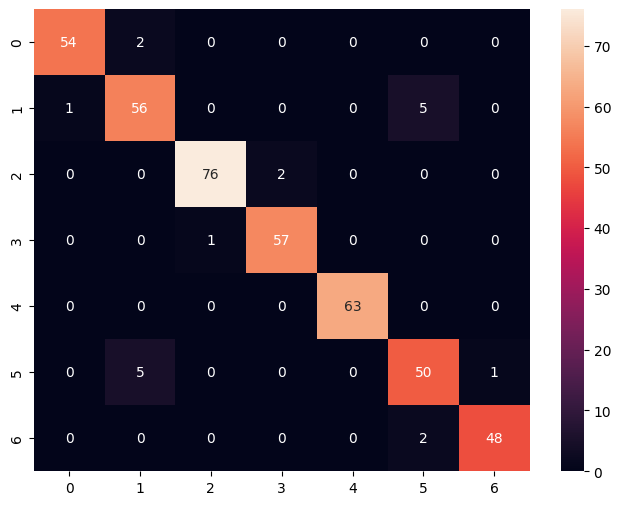

In [18]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

Compare Models

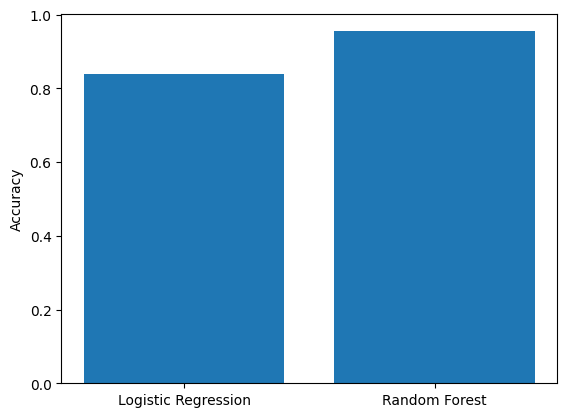

In [19]:
models = [
    'Logistic Regression',
    'Random Forest'
]

accuracy = [
    lr_acc,
    rf_acc
]

plt.bar(
    models,
    accuracy
)

plt.ylabel("Accuracy")

plt.show()

Feature Importance

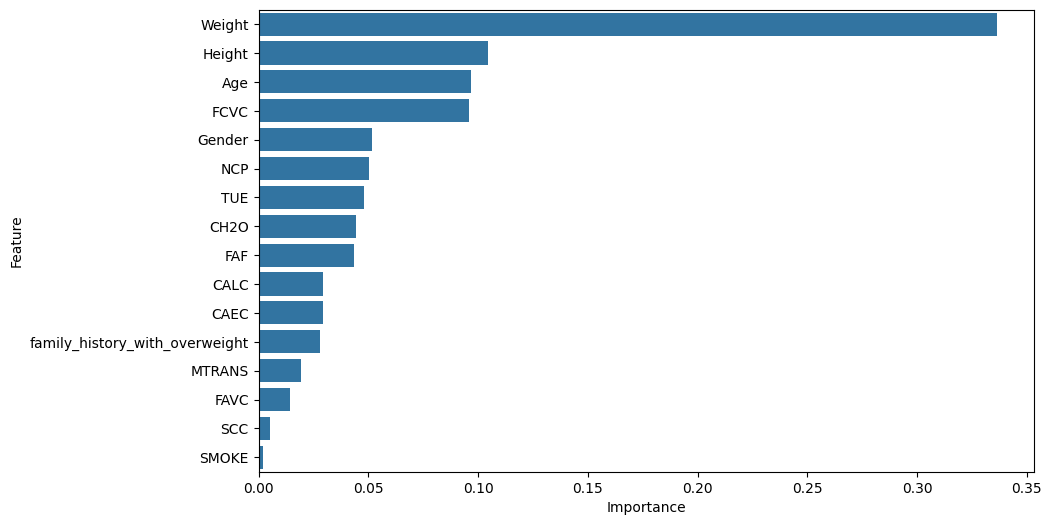

In [20]:
importance = rf.feature_importances_

imp_df = pd.DataFrame({
    'Feature':X.columns,
    'Importance':importance
})

imp_df = imp_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=imp_df
)

plt.show()

Diet Recommendation Function

In [21]:
def diet_recommendation(obesity_class):

    recommendations = {

        "Insufficient_Weight":
            (2800,3.0),

        "Normal_Weight":
            (2200,2.5),

        "Overweight_Level_I":
            (2000,3.0),

        "Overweight_Level_II":
            (1800,3.5),

        "Obesity_Type_I":
            (1700,3.5),

        "Obesity_Type_II":
            (1500,4.0),

        "Obesity_Type_III":
            (1300,4.5)
    }

    return recommendations[obesity_class]

User Prediction System

After training:

In [22]:
target_decoder = label_encoders['NObeyesdad']

Create a sample user:

In [23]:
sample = [[
1,
25,
1.75,
85,
1,
1,
2.5,
3,
2,
0,
2.5,
0,
2,
1,
1,
3
]]

Predict:

In [24]:
pred = rf.predict(sample)

obesity_class = target_decoder.inverse_transform(pred)[0]

print(
    "Predicted Class:",
    obesity_class
)

Predicted Class: Overweight_Level_II


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Calorie & Water Recommendation

In [25]:
calories,water = diet_recommendation(
    obesity_class
)

print(
    "Daily Calories:",
    calories,
    "kcal"
)

print(
    "Daily Water Intake:",
    water,
    "liters"
)

Daily Calories: 1800 kcal
Daily Water Intake: 3.5 liters
